In [16]:
import pandas as pd
from pathlib import Path

# Load dataset
project_root = Path.cwd().parent
data_path = project_root / "data" / "GlobalWeatherRepository.csv"

df = pd.read_csv(data_path)

df["last_updated"] = pd.to_datetime(df["last_updated"])

# Select Amman temperature
city_df = df[df["location_name"] == "Amman"].copy()

city_df = city_df.sort_values("last_updated")

daily_temperature_df = (
    city_df[["last_updated", "temperature_celsius"]]
    .set_index("last_updated")
    .resample("D")
    .mean()
    .ffill()
    .reset_index()
)

daily_temperature_df.head()


,last_updated,temperature_celsius
0,2024-05-16,24.0
1,2024-05-17,27.0
2,2024-05-18,30.0
3,2024-05-19,29.0
4,2024-05-20,30.0


In [18]:
daily_temperature_df["naive_prediction"] = (
    daily_temperature_df["temperature_celsius"].shift(1)
)
baseline_df = daily_temperature_df.dropna()

baseline_df.head()

,last_updated,temperature_celsius,naive_prediction
1,2024-05-17,27.0,24.0
2,2024-05-18,30.0,27.0
3,2024-05-19,29.0,30.0
4,2024-05-20,30.0,29.0
5,2024-05-21,29.0,30.0


In [22]:
# Split data into train and test (80/20) without shuffle

split_index = int(len(daily_temperature_df) * 0.8)

train_df = daily_temperature_df.iloc[:split_index].copy()
test_df = daily_temperature_df.iloc[split_index:].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print(train_df.tail())
print(test_df.head())

Train size: 628
Test size: 158
    last_updated  temperature_celsius  naive_prediction
623   2026-01-29                  9.0               9.3
624   2026-01-30                 11.3               9.0
625   2026-01-31                  9.2              11.3
626   2026-02-01                 13.3               9.2
627   2026-02-02                 15.2              13.3
    last_updated  temperature_celsius  naive_prediction
628   2026-02-03                  9.8              15.2
629   2026-02-04                  9.2               9.8
630   2026-02-05                 11.4               9.2
631   2026-02-06                 13.1              11.4
632   2026-02-07                 13.0              13.1


In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare train and test series
train_series = train_df.set_index("last_updated")["temperature_celsius"]
test_series = test_df.set_index("last_updated")["temperature_celsius"]

# Build SARIMA model
model = SARIMAX(
    train_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

# Train model
sarima_model = model.fit()

print(sarima_model.summary())

c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                     
Dep. Variable:               temperature_celsius   No. Observations:                  628
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1465.780
Date:                           Sun, 12 Jul 2026   AIC                           2941.561
Time:                                   01:17:32   BIC                           2963.709
Sample:                               05-16-2024   HQIC                          2950.170
                                    - 02-02-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6973      0.044     15.829      0.000       0.611       0.784
ma.L1         -0.9149      0.024    -37.539

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast = sarima_model.forecast(steps=len(test_series))
mae = mean_absolute_error(test_series, forecast)

rmse = np.sqrt(
    mean_squared_error(test_series, forecast)
)
print("MAE:", mae)
print("RMSE:", rmse)


MAE: 11.841224838872359
RMSE: 14.480171108870588


In [30]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_series, forecast) * 100

print("MAPE:", mape, "%")

MAPE: 61.10639508256994 %


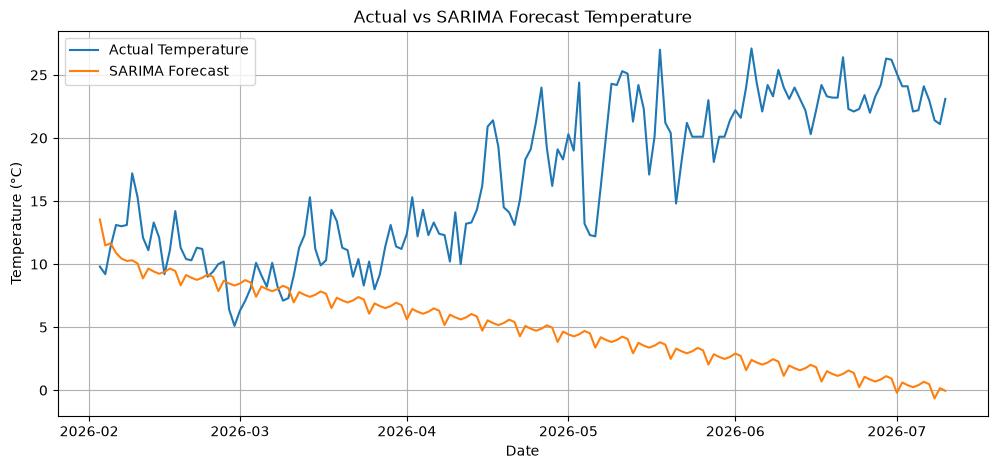

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test_series.index,
    test_series,
    label="Actual Temperature"
)

plt.plot(
    test_series.index,
    forecast,
    label="SARIMA Forecast"
)

plt.title("Actual vs SARIMA Forecast Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid()

plt.show()

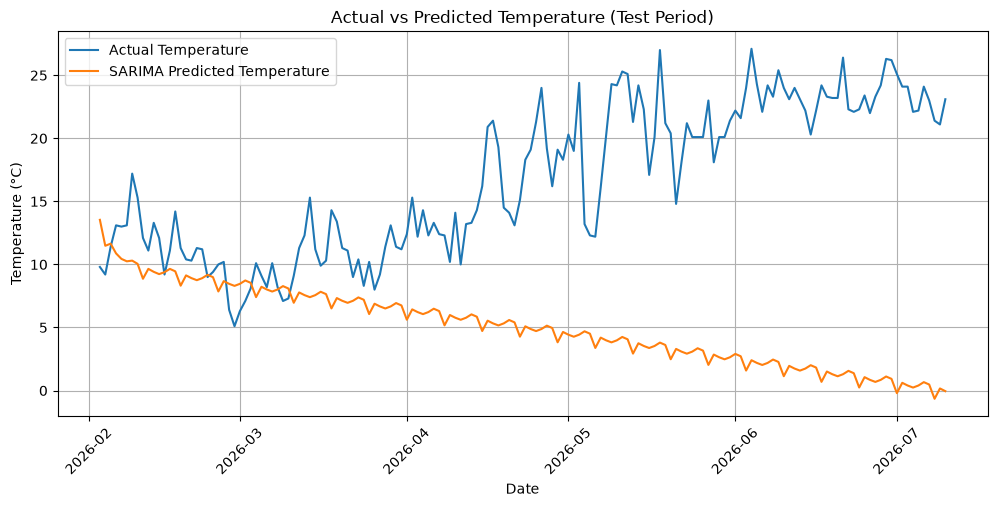

In [33]:
forecast = sarima_model.forecast(steps=len(test_series))
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    test_series.index,
    test_series,
    label="Actual Temperature"
)

plt.plot(
    test_series.index,
    forecast,
    label="SARIMA Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature (Test Period)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid()

plt.xticks(rotation=45)

plt.show()